In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [10]:
df=pd.read_csv("spambase_csv.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [9]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [12]:
df.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [15]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

print("Feature X (57 cols):",X.shape)
print("Target Y (class):",y.shape)

Feature X (57 cols): (4601, 57)
Target Y (class): (4601,)


In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scale=scaler.fit_transform(X)

In [23]:
print(X_scale)

[[-3.42433707e-01  3.30884903e-01  7.12858774e-01 ... -4.52472762e-02
   4.52979198e-02 -8.72413388e-03]
 [ 3.45359395e-01  5.19091945e-02  4.35129540e-01 ... -2.44326749e-03
   2.50562832e-01  1.22832407e+00]
 [-1.45921392e-01 -1.65071912e-01  8.51723390e-01 ...  1.45920848e-01
   2.22110599e+00  3.25873251e+00]
 ...
 [ 6.40127868e-01 -1.65071912e-01  3.83734930e-02 ... -1.19382054e-01
  -2.36941335e-01 -2.72627750e-01]
 [ 2.80176333e+00 -1.65071912e-01 -5.56760578e-01 ... -1.27482666e-01
  -2.42072958e-01 -3.38603654e-01]
 [-3.42433707e-01 -1.65071912e-01  7.32696576e-01 ... -1.24236117e-01
  -2.42072958e-01 -4.01280763e-01]]


In [24]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,0.059824,0.541702,0.093930,0.058626,0.049205,0.248848,0.142586,0.184745,1.662100,0.085577,0.809761,0.121202,0.101645,0.094269,0.549504,0.265384,0.767305,0.124845,0.098915,0.102852,0.064753,0.047048,0.097229,0.047835,0.105412,0.097477,0.136953,0.013201,0.078629,0.064834,0.043667,0.132339,0.046099,0.079196,0.301224,0.179824,0.005444,0.031869,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,0.201545,0.861698,0.301036,0.335184,0.258843,0.825792,0.444055,0.531122,1.775481,0.509767,1.200810,1.025756,0.350286,0.442636,1.671349,0.886955,3.367292,0.538576,0.593327,0.456682,0.403393,0.328559,0.555907,0.329445,0.532260,0.402623,0.423451,0.220651,0.434672,0.349916,0.361205,0.766819,0.223812,0.621976,1.011687,0.911119,0.076274,0.285735,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.310000,0.000000,0.220000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

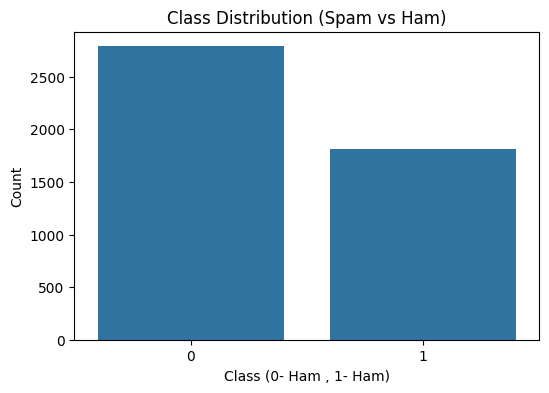

In [26]:
#Class distribution (Spam and Ham)

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution (Spam vs Ham)")

plt.xlabel("Class (0- Ham , 1- Ham)")
plt.ylabel("Count")
plt.show()

In [ ]:
print(y.value_counts(normalize=True)*100)

#    60.6 % ham
#    39.4 % Spam

class
0    60.595523
1    39.404477
Name: proportion, dtype: float64


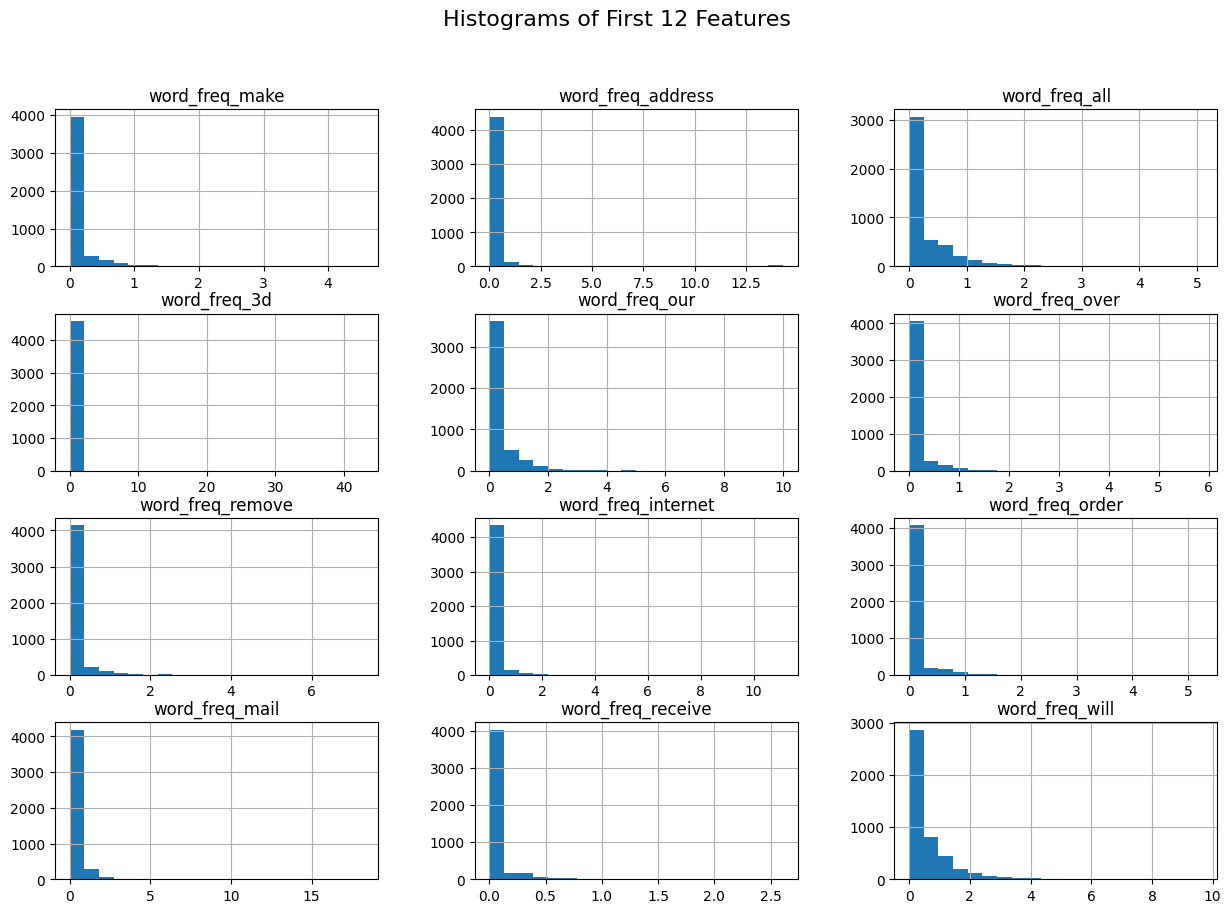

In [37]:
df.iloc[:, :12].hist(figsize=(15,10), bins=20)
plt.suptitle("Histograms of First 12 Features", fontsize=16)
plt.show()

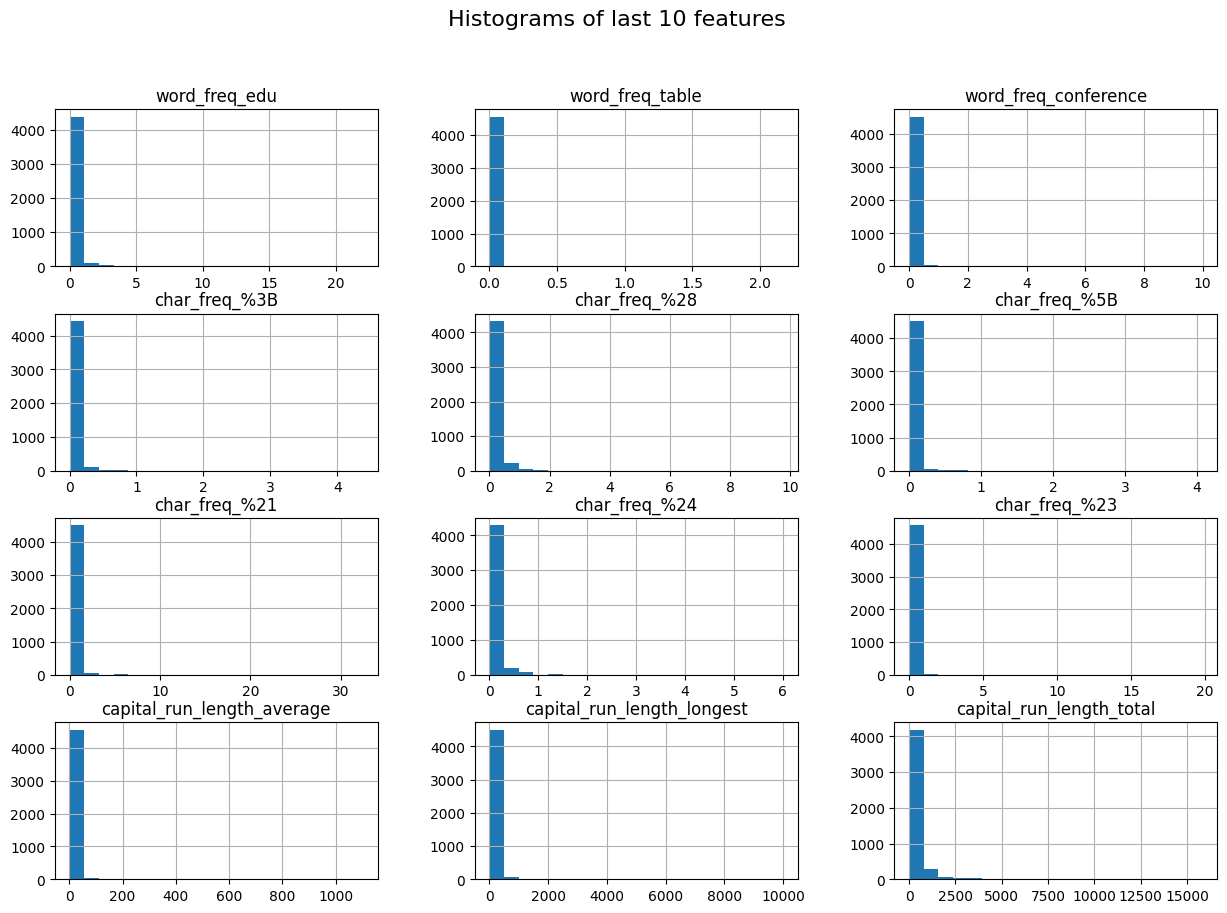

In [49]:
df.iloc[:,-13:-1].hist(figsize=(15,10),bins=20)
plt.suptitle("Histograms of last 10 features",fontsize=16)
plt.show()

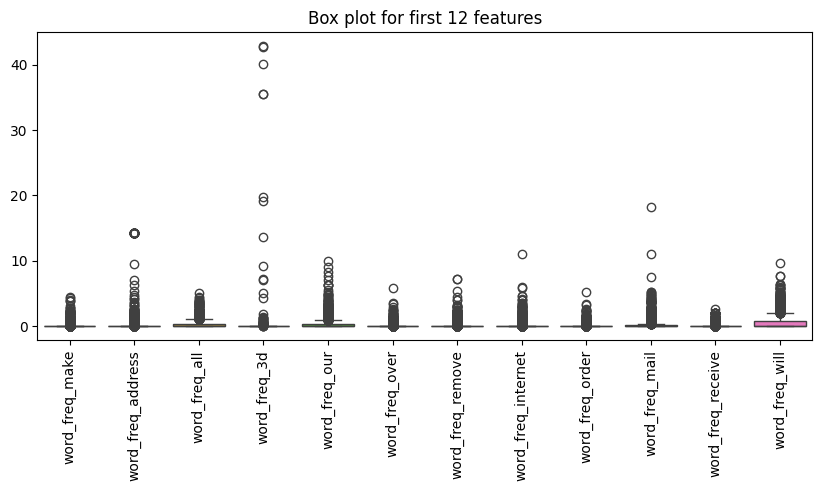

In [47]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df.iloc[:,:12])
plt.xticks(rotation=90)
plt.title("Box plot for first 12 features")
plt.show()

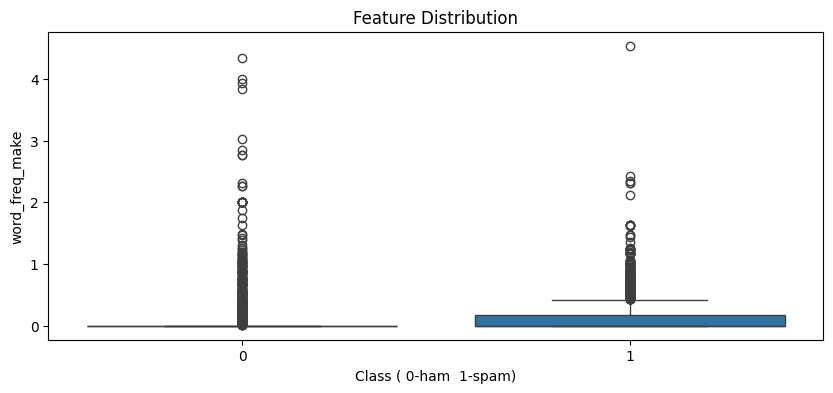

In [51]:
plt.figure(figsize=(10,4))
sns.boxplot(x=y,y=df.iloc[:,0])
plt.title("Feature Distribution")
plt.xlabel("Class ( 0-ham  1-spam)")
plt.show()

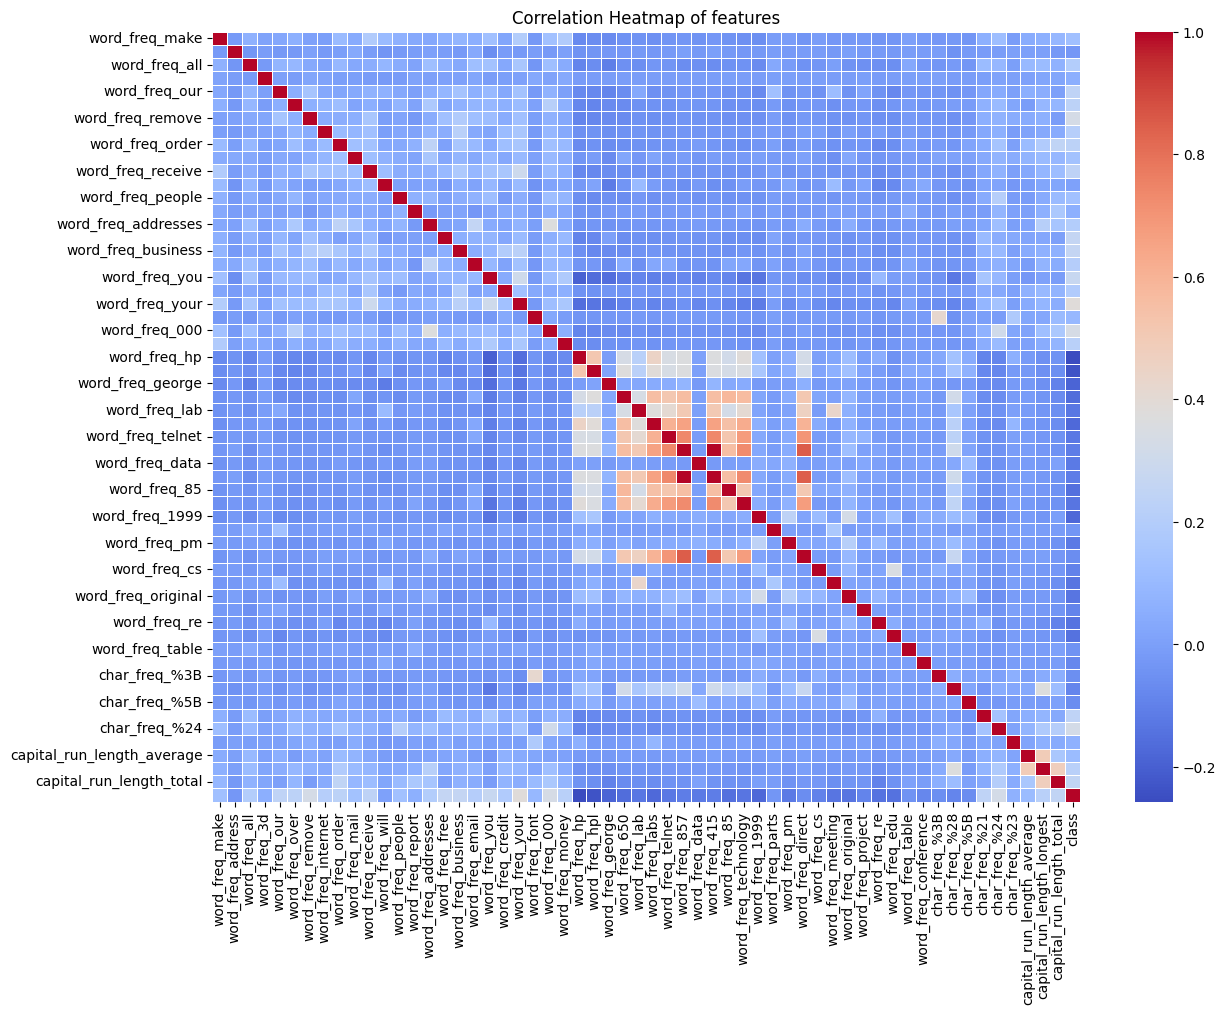

In [52]:
#heatmap

corr=df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr,cmap="coolwarm",linewidth=0.5)
plt.title("Correlation Heatmap of features")
plt.show()

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scale, y, test_size=0.2, random_state=42
)

# 80 20 split



In [56]:
from sklearn.linear_model import LogisticRegression
import time

lr=LogisticRegression(max_iter=500)
start=time.time()
lr.fit(X_train,y_train)
lr_t=time.time()-start


In [62]:
from sklearn.metrics import (accuracy_score,precision_score,confusion_matrix,f1_score,classification_report)

y_predict_lr=lr.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_predict_lr))
print("Precision:", precision_score(y_test,y_predict_lr))
print("Training time: ",lr_t)

print("\nClassification report")
print(classification_report(y_test,y_predict_lr))

Accuracy:  0.9196525515743756
Precision: 0.9316939890710383
Training time:  0.030908823013305664

Classification report
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       531
           1       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



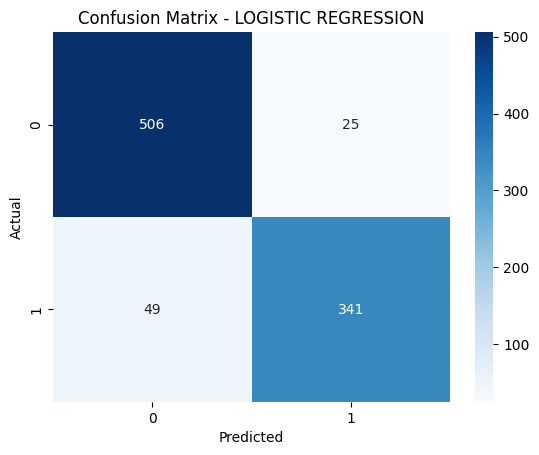

In [59]:
# confusion matrix (Logistic Regression)


cm_lr=confusion_matrix(y_test,y_predict_lr)
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix - LOGISTIC REGRESSION")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
from sklearn.model_selection import GridSearchCV

par_grid_lr={
  "C":[0.01,0.1,1,10,100],
  "penalty":["l1","l2"],
  "solver":["liblinear","saga"]
}

grid_lr=GridSearchCV(LogisticRegression(max_iter=500),par_grid_lr,cv=5,scoring="f1",n_jobs=-1)

grid_lr.fit(X_train,y_train)

,estimator,LogisticRegre...(max_iter=500)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [61]:
best_lr=grid_lr.best_estimator_
print("Best Parameters:", grid_lr.best_params_)
print("Best CV score:",grid_lr.best_score_)



Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV score: 0.9042747136004097


In [64]:
#SVM (support vector machine)
from sklearn.svm import SVC
kernels=["linear","poly","rbf","sigmoid"]

svm_res={}
for k in kernels:
  svm=SVC(kernel=k)
  start=time.time()
  svm.fit(X_train,y_train)
  svm_time=time.time()-start

  y_pred=svm.predict(X_test)

  svm_res[k]={
    "Accuracy": accuracy_score(y_test,y_pred),
    "F1Score": f1_score(y_test,y_pred),
    "Training Time": svm_time
  }

svm_res

{'linear': {'Accuracy': 0.9250814332247557,
  'F1Score': 0.9090909090909091,
  'Training Time': 1.443279504776001},
 'poly': {'Accuracy': 0.7643865363735071,
  'F1Score': 0.629059829059829,
  'Training Time': 0.9265141487121582},
 'rbf': {'Accuracy': 0.9348534201954397,
  'F1Score': 0.9206349206349206,
  'Training Time': 0.5900046825408936},
 'sigmoid': {'Accuracy': 0.8892508143322475,
  'F1Score': 0.8664921465968587,
  'Training Time': 0.4036233425140381}}

In [70]:
par_grid_svm={
  "kernel":["linear","poly","rbf","sigmoid"],
  "C":[0.1,1,10,100],
  "gamma":["scale","auto"],
  "degree":[2,3,4]
}

grid_svm=GridSearchCV(SVC(),par_grid_svm,cv=5,scoring="f1",n_jobs=-1)

grid_svm.fit(X_train,y_train)

y_pred_svm=grid_svm.predict(X_test)
best_svm = grid_svm.best_estimator_
print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

print(classification_report(y_test,y_pred_svm))

Best Parameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9088718064863981
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       531
           1       0.95      0.89      0.92       390

    accuracy                           0.93       921
   macro avg       0.94      0.93      0.93       921
weighted avg       0.94      0.93      0.93       921



In [69]:
from sklearn.model_selection import cross_val_score

lr_cv=cross_val_score(best_lr,X_scale,y,cv=5,scoring="f1")
svm_cv=cross_val_score(best_svm,X_scale,y,cv=5,scoring="f1")

print("Logistic Regression CV Scores:", lr_cv)
print("SVM CV Scores:", svm_cv)


Logistic Regression CV Scores: [0.89428571 0.91213389 0.87564767 0.93502825 0.78795812]
SVM CV Scores: [0.91292135 0.91396333 0.93646409 0.9323741  0.80833333]


OBSERVATION

-> Logistic Regression is fast, simple, and interpretable

-> SVM with RBF kernel gives best classification performance

-> Regularization (C) controls overfitting

-> SVM has higher computational cost
